In [1]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


df = pd.read_csv("weather.csv")  

print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

print(df.info())

| Outlook   | Temp   | Humidity   | Windy   | Play   |
|:----------|:-------|:-----------|:--------|:-------|
| rainy     | hot    | high       | 0       | 0      |
| rainy     | hot    | high       | 1       | 0      |
| overcast  | hot    | high       | 0       | 1      |
| sunny     | mild   | high       | 0       | 1      |
| sunny     | cool   | normal     | 0       | 1      |
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Outlook   14 non-null     object
 1   Temp      14 non-null     object
 2   Humidity  14 non-null     object
 3   Windy     14 non-null     int64 
 4   Play      14 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 692.0+ bytes
None


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Create a OneHotEncoder object
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit the encoder on the categorical columns and transform them
encoded_data = encoder.fit_transform(df[['Outlook', 'Temp', 'Humidity']])

# Create a new DataFrame with the encoded columns
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Outlook',  
 'Temp', 'Humidity']))

# Drop the original categorical columns from the original DataFrame
df = df.drop(['Outlook', 'Temp', 'Humidity'], axis=1)

# Concatenate the encoded DataFrame with the original DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Separate features and target variable
X = df.drop('Play', axis=1)
y = df['Play']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display  the first 5 rows
print(X_train.head().to_markdown(index=False, numalign="left", stralign="left"))

# Print the column names and their data types
print(X_train.info())


| Windy   | Outlook_overcast   | Outlook_rainy   | Outlook_sunny   | Temp_cool   | Temp_hot   | Temp_mild   | Humidity_high   | Humidity_normal   |
|:--------|:-------------------|:----------------|:----------------|:------------|:-----------|:------------|:----------------|:------------------|
| 0       | 1                  | 0               | 0               | 0           | 1          | 0           | 0               | 1                 |
| 1       | 0                  | 0               | 1               | 1           | 0          | 0           | 0               | 1                 |
| 0       | 0                  | 1               | 0               | 1           | 0          | 0           | 0               | 1                 |
| 0       | 1                  | 0               | 0               | 0           | 1          | 0           | 1               | 0                 |
| 1       | 0                  | 1               | 0               | 0           | 1          | 0           | 1 

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


models = [
    DecisionTreeClassifier(criterion="gini", max_depth=None, random_state=42),  # Default (gini)
    DecisionTreeClassifier(criterion="entropy", max_depth=None, random_state=42),  # Entropy
    DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42),  # Max depth 3
    DecisionTreeClassifier(criterion="gini", min_samples_split=5, random_state=42),  # Min samples split 5
]

# Train and evaluate each model
for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model: {model}")
    print(f"Accuracy: {accuracy:.4f}\n")

Model: DecisionTreeClassifier(random_state=42)
Accuracy: 1.0000

Model: DecisionTreeClassifier(criterion='entropy', random_state=42)
Accuracy: 1.0000

Model: DecisionTreeClassifier(max_depth=3, random_state=42)
Accuracy: 1.0000

Model: DecisionTreeClassifier(min_samples_split=5, random_state=42)
Accuracy: 1.0000



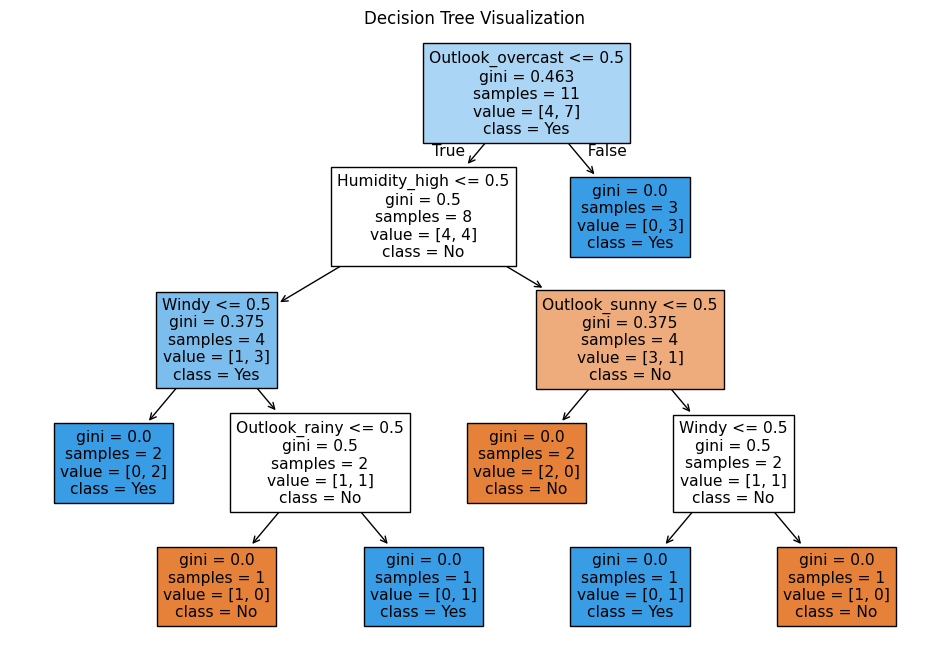

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot the decision tree for the first model
plt.figure(figsize=(12, 8))
plot_tree(models[0], feature_names=X.columns, class_names=["No", "Yes"], filled=True)
plt.title("Decision Tree Visualization")

# Save the plot as an image file
plt.savefig("decision_tree_plot.png")


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split


def entropy(y):
    if len(y) == 0:
        return 0
    unique_labels, counts = np.unique(y, return_counts=True)
    proportions = counts / len(y)
    entropy = -np.sum(proportions * np.log2(proportions))
    return entropy


def information_gain(y, x):
    info_gain = entropy(y)
    unique_values, counts = np.unique(x, return_counts=True)
    for value, count in zip(unique_values, counts):
        subset_indices = x == value
        subset_y = y[subset_indices]
        info_gain -= (count / len(y)) * entropy(subset_y)
    return info_gain


def id3(x, y, features):
    if len(np.unique(y)) == 1:
        return y[0]
    if len(features) == 0:
        return np.argmax(np.bincount(y))
    info_gains = [information_gain(y, x[:, i]) for i in range(x.shape[1])]
    best_feature_index = np.argmax(info_gains)
    best_feature = features[best_feature_index]
    tree = {best_feature: {}}
    remaining_features = [f for f in features if f != best_feature]
    unique_values = np.unique(x[:, best_feature_index])
    for value in unique_values:
        subset_indices = x[:, best_feature_index] == value
        subset_x = x[subset_indices]
        subset_y = y[subset_indices]
        subtree = id3(subset_x, subset_y, remaining_features)
        tree[best_feature][value] = subtree
    return tree


for col in ['Windy', 'Outlook_overcast', 'Outlook_rainy', 'Outlook_sunny', 'Temp_cool', 'Temp_hot',
            'Temp_mild', 'Humidity_high', 'Humidity_normal']:
    X_train[col] = pd.to_numeric(X_train[col])


X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

features = X_train.columns.tolist()
decision_tree = id3(X_train_np, y_train_np, features)

# Print the decision tree
print(decision_tree)

In [6]:

from sklearn.tree import export_graphviz
from graphviz import Source

# Export the decision tree in DOT format
dot_data = export_graphviz(models[0], out_file=None, 
                           feature_names=X.columns,  
                           class_names=["No", "Yes"],  
                           filled=True, rounded=True,  
                           special_characters=True)  

# Create a graphviz Source object from the DOT data
graph = Source(dot_data)  

# Render and save the tree as a PNG image
graph.render("decision_tree_visualization", format="png")

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH